# Clase 5 · Regresión simple y múltiple, e inferencia con bootstrap

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

**Qué hacemos hoy.** Primero, lo que quedó pendiente de la clase 4: la regresión simple de la motorización, ponderada por el factor, la misma regresión en tres escalas, y la regresión múltiple con sus variables dummies y el R² ajustado. Después, lo de las slides de hoy: cuánto se mueve la pendiente de una muestra a otra, con el bootstrap, y de dónde sale el error estándar del summary de statsmodels.

**La pregunta de la clase:** ¿la pendiente de −4,8 minutos por millón, calculada con 45 comunas, es real o es azar?

## 1. Preparación

Los datos de siempre: viajes y hogares de la EOD, y la tabla por comuna de la clase 3, ponderada por el factor, con su recta.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
# scipy.stats: las distribuciones de probabilidad con nombre
from scipy import stats

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Si clonó el repositorio del curso, los datos ya están en su disco:
# BASE = "datos/eod_stgo/"

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)

# La población de hoy: la duración de cada viaje, sin faltantes ni ceros
duracion = viajes["TiempoViaje"].dropna()
duracion = duracion[duracion > 0]
len(duracion)

113113

In [4]:
# La tabla por comuna de la clase 3: medias ponderadas por el factor
viajes_final = viajes.merge(
    hogares[["Hogar", "Comuna", "IngresoHogar", "NumVeh", "NumPer"]], on="Hogar")
viajes_final = viajes_final.dropna(
    subset=["FactorLaboralNormal", "TiempoViaje", "IngresoHogar"]).copy()

w = viajes_final["FactorLaboralNormal"]
for col in ["IngresoHogar", "TiempoViaje"]:
    viajes_final["w_" + col] = w * viajes_final[col]

suma = viajes_final.groupby("Comuna").sum(numeric_only=True)
por_comuna = pd.DataFrame({
    "ingreso": suma["w_IngresoHogar"] / suma["FactorLaboralNormal"],
    "duracion": suma["w_TiempoViaje"] / suma["FactorLaboralNormal"],
    "n": viajes_final.groupby("Comuna").size()}).reset_index()
por_comuna = por_comuna[por_comuna["n"] >= 200]
len(por_comuna)
por_comuna.head()

,Comuna,ingreso,duracion,n
0,BUIN,611584.779504,27.767868,889
1,CALERA DE TANGO,609311.812531,39.746297,629
2,CERRILLOS,578682.733281,34.824237,760
3,CERRO NAVIA,457758.557018,36.010691,1113
4,COLINA,636524.561820,32.607995,1177


In [5]:
# La recta de la clase 3 y sus residuos
pendiente, intercepto = np.polyfit(por_comuna["ingreso"] / 1e6,
                                   por_comuna["duracion"], 1)

In [6]:
print(f"pendiente: {pendiente:.3f}, intercepto: {intercepto:.3f}")

pendiente: -4.815, intercepto: 38.335


In [7]:
por_comuna["prediccion"] = intercepto + pendiente * por_comuna["ingreso"] / 1e6
por_comuna["residuo"] = por_comuna["duracion"] - por_comuna["prediccion"]
por_comuna.head()

,Comuna,ingreso,duracion,n,prediccion,residuo
0,BUIN,611584.779504,27.767868,889,35.390729,-7.622861
1,CALERA DE TANGO,609311.812531,39.746297,629,35.401672,4.344625
2,CERRILLOS,578682.733281,34.824237,760,35.549138,-0.724901
3,CERRO NAVIA,457758.557018,36.010691,1113,36.131335,-0.120645
4,COLINA,636524.561820,32.607995,1177,35.270655,-2.662659


### La misma recta con statsmodels: OLS

`np.polyfit` entrega solo los dos números. **OLS** (ordinary least squares, mínimos cuadrados ordinarios) de statsmodels ajusta la misma recta y devuelve un objeto con todo lo demás: `.params` son los coeficientes, `.predict(X)` calcula la predicción para las filas de `X` (las mismas u otras nuevas), `.fittedvalues` son las predicciones sobre los datos del ajuste, `.resid` los residuos, y `.summary().tables[1]` la tabla de coeficientes que leeremos completa en la sección 5.

**La constante.** OLS no agrega el intercepto por su cuenta: ajusta un coeficiente por cada columna de `X`, y nada más. Con solo la columna ingreso, la recta pasaría obligada por el origen. Para que tenga intercepto se le pasa una columna extra llena de unos, `const`; el modelo queda duración = a · 1 + b · ingreso, y a es el coeficiente de esa columna. Eso es lo único que hace `sm.add_constant`. Por eso `.params` trae dos números: const = 38,3 (el intercepto) e ingreso = −4,8 (la pendiente):

In [8]:
X = sm.add_constant(por_comuna["ingreso"] / 1e6)   # el ingreso en millones, más la constante
modelo_c = sm.OLS(por_comuna["duracion"], X).fit()
print(modelo_c.params.round(2))



const      38.34
ingreso    -4.81
dtype: float64


In [9]:
# Las predicciones y los residuos salen del modelo ajustado
por_comuna["prediccion_ols"] = modelo_c.predict(X)   # lo mismo que modelo_c.fittedvalues
por_comuna["residuo_ols"] = modelo_c.resid
por_comuna[["Comuna", "duracion", "prediccion", "prediccion_ols", "residuo_ols"]].head()

,Comuna,duracion,prediccion,prediccion_ols,residuo_ols
0,BUIN,27.767868,35.390729,35.390729,-7.622861
1,CALERA DE TANGO,39.746297,35.401672,35.401672,4.344625
2,CERRILLOS,34.824237,35.549138,35.549138,-0.724901
3,CERRO NAVIA,36.010691,36.131335,36.131335,-0.120645
4,COLINA,32.607995,35.270655,35.270655,-2.662659


Para predecir en una comuna que no hemos visto, lo más simple es la **API de fórmulas** de statsmodels: la recta se escribe como texto, `duracion ~ ingreso_m` (la respuesta a la izquierda de `~`, las variables a la derecha), el intercepto va incluido sin columnas de unos, y `predict` recibe una tabla con solo el ingreso de la comuna nueva:

In [10]:
import statsmodels.formula.api as smf

por_comuna["ingreso_m"] = por_comuna["ingreso"] / 1e6   # el ingreso en millones, con nombre propio
modelo_f = smf.ols("duracion ~ ingreso_m", data=por_comuna).fit()
print(modelo_f.params.round(2))   # Intercept es a; ingreso_m es b

Intercept    38.34
ingreso_m    -4.81
dtype: float64


In [11]:
# Una comuna que no hemos visto, con ingreso medio de 1,5 millones
nueva = pd.DataFrame({"Comuna": ["Nueva Comuna"], "ingreso_m": [1.5]})
nueva["prediccion"] = modelo_f.predict(nueva)
nueva

,Comuna,ingreso_m,prediccion
0,Nueva Comuna,1.5,31.113395


In [12]:
# Lo mismo a mano, con el intercepto y la pendiente que guarda el modelo
a, b = modelo_f.params["Intercept"], modelo_f.params["ingreso_m"]
print(f"{a:.2f} + ({b:.2f}) · 1,5 = {a + b * 1.5:.1f} min")

38.34 + (-4.81) · 1,5 = 31.1 min


In [13]:
print("R²:", round(modelo_f.rsquared, 3))

R²: 0.117


In [14]:
modelo_c.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               duracion   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     5.707
Date:                Tue, 08 Sep 2026   Prob (F-statistic):             0.0214
Time:                        15:19:00   Log-Likelihood:                -139.50
No. Observations:                  45   AIC:                             283.0
Df Residuals:                      43   BIC:                             286.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.3352      1.773     21.622      0.000      34.760      41.911
ingreso       -4.8146      2.015     -2.389      0.021      -8.879      -0.750
==============================================================================
Omnibus:                        2.948   Durbin-Watson:                   1.936
Prob(Omnibus):                  0.229   Jarque-Bera (JB):                2.776
Skew:                           0.556   Prob(JB):                        0.250
Kurtosis:                       2.504   Cond. No.                         4.12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [15]:
# La tabla de coeficientes, que hoy leeremos completa
modelo_c.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,38.3352,1.773,21.622,0.000,34.760,41.911
ingreso,-4.8146,2.015,-2.389,0.021,-8.879,-0.750


## 2. Regresión simple: la motorización, ponderada por el factor

Esta parte quedó pendiente de la clase 4: la regresión simple con statsmodels, ponderada por el factor de expansión.

### La motorización: vehículos según el ingreso

**Objetivo:** modelar cuántos vehículos tiene un hogar según su ingreso, ahora con datos desagregados (un hogar por fila).

Los modelos de propiedad de vehículos son estándar en ingeniería de transporte: ¿cuántos autos tendrá un hogar según su ingreso? Aquí cada fila es un hogar de verdad, 18.264, no un agregado. Como la conclusión es sobre la ciudad, cada hogar pesa según su factor de expansión: la versión ponderada de OLS se llama **WLS** (weighted least squares, mínimos cuadrados ponderados) y recibe los pesos en `weights`:

In [16]:
h = hogares.dropna(subset=["IngresoHogar", "NumVeh", "Factor"]).copy()
h.head()

,Hogar,Sector,Zona,Comuna,DirCoordX,DirCoordY,Fecha,DiaAsig,TipoDia,Temporada,...,NumVeh,NumBicAdulto,NumBicNino,Propiedad,MontoDiv,ImputadoDiv,MontoArr,ImputadoArr,IngresoHogar,Factor
0,100010,7,786,BUIN,335180.8019,6266420.975,14-04-2013,domingo,2,1,...,1,1,0,2,53000.0,0,100000,0,450845,136.393738
1,100020,7,785,BUIN,338410.2114,6265607.141,10-04-2013,miércoles,1,1,...,1,3,0,1,NaN,0,120000,0,1019369,73.843597
2,100030,7,791,BUIN,327863.8248,6257800.086,23-08-2013,viernes,1,1,...,0,0,0,3,NaN,0,70000,0,80000,180.722809
3,100041,7,791,BUIN,327864.0000,6257800.000,23-08-2013,viernes,1,1,...,0,1,0,1,NaN,0,80000,0,559259,150.379059
4,100052,7,783,BUIN,338480.8152,6267296.941,08-08-2013,jueves,1,1,...,0,0,0,1,NaN,0,117771,1,710309,122.001518


In [17]:
x = h["IngresoHogar"] / 1e6   # el ingreso en millones
y = h["NumVeh"] # el numero de vehículos de cada hogar
w = h["Factor"] # el factor de expansión de cada hogar

# WLS: la versión ponderada de OLS
modelo_w = sm.WLS(y, sm.add_constant(x), weights=w).fit()
print(modelo_w.params.round(3))

const           0.200
IngresoHogar    0.501
dtype: float64


In [18]:
print("R²:", round(modelo_w.rsquared, 3))

R²: 0.261


**Medio vehículo más por cada millón** de ingreso. A nivel de hogar la correlación es 0,47.

## 3. La duración y la distancia: la misma regresión, tres veces

**Objetivo:** elegir el modelo que merecen unos datos con cola larga, probando la misma regresión en tres escalas. Para eso necesitamos la distancia de cada viaje, que viene en otra tabla:

In [19]:
distancias = pd.read_csv(BASE + "DistanciaViaje.csv", sep=";", decimal=",")
distancias.head()

,Viaje,DistEuclidiana,DistManhattan,Imputada
0,1000100101,-1,-1,0
1,1000100102,-1,-1,0
2,1000100201,-1,-1,0
3,1000100202,-1,-1,0
4,1000100203,-1,-1,0


Ahí están los −1: el tercer faltante disfrazado del curso (tras las coordenadas en 0 y los códigos 999). Contémoslos, y unamos la distancia a los viajes con su llave:

In [20]:
# ¿Cuántos viajes no tienen distancia?
(distancias["DistEuclidiana"] < 0).sum()

np.int64(10857)

In [21]:
viajes.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,TiempoMedio,Periodo,MinutosDespues,CuadrasDespues,FactorLaboralNormal,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,3.0,6.0,6.0,1.0,1.000000,NaN,NaN,NaN,NaN,0.0
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,4.0,5.0,5.0,1.0,1.127220,NaN,NaN,NaN,NaN,0.0
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,3.0,5.0,10.0,2.0,1.127220,NaN,NaN,NaN,NaN,0.0
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,2.0,5.0,10.0,2.0,1.127220,NaN,NaN,NaN,NaN,0.0
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,5.0,4.0,10.0,2.0,1.052764,NaN,NaN,NaN,NaN,0.0


In [22]:
ok = viajes.merge(distancias, on="Viaje")

# Fuera los -1 (faltantes) y los viajes sin duración
ok = ok[ok["DistEuclidiana"] >= 0].dropna(subset=["TiempoViaje"])

# De metros a kilómetros
ok["DistKm"] = ok["DistEuclidiana"] / 1000
len(ok)

102483

In [23]:
ok["DistKm"].describe().round(2)

count    102483.00
mean          6.23
std          13.05
min           0.00
25%           0.83
50%           3.06
75%           8.54
max        1258.47
Name: DistKm, dtype: float64

Mediana 3 km, pero un máximo de 1.258: imposible dentro de la Región Metropolitana (el checklist de rangos válidos de la clase 2, otra vez). Cortamos en 150 km, el ancho generoso de la región:

In [24]:
ok = ok[ok["DistKm"] <= 150]
len(ok)

102422

In [25]:
ok.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorLaboralNormal,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,DistEuclidiana,DistManhattan,Imputada,DistKm
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,1.000000,NaN,NaN,NaN,NaN,0.0,5387,7608,0,5.387
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,1.127220,NaN,NaN,NaN,NaN,0.0,18841,26100,0,18.841
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,1.127220,NaN,NaN,NaN,NaN,0.0,18841,26100,0,18.841
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,1.127220,NaN,NaN,NaN,NaN,0.0,13392,17589,0,13.392
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,1.052764,NaN,NaN,NaN,NaN,0.0,13392,17589,0,13.392


In [26]:
# El logaritmo no acepta ceros: fuera los 27 viajes que parten
# y llegan al mismo punto (distancia 0)
dist_pos = ok.loc[ok["DistKm"] > 0, "DistKm"]

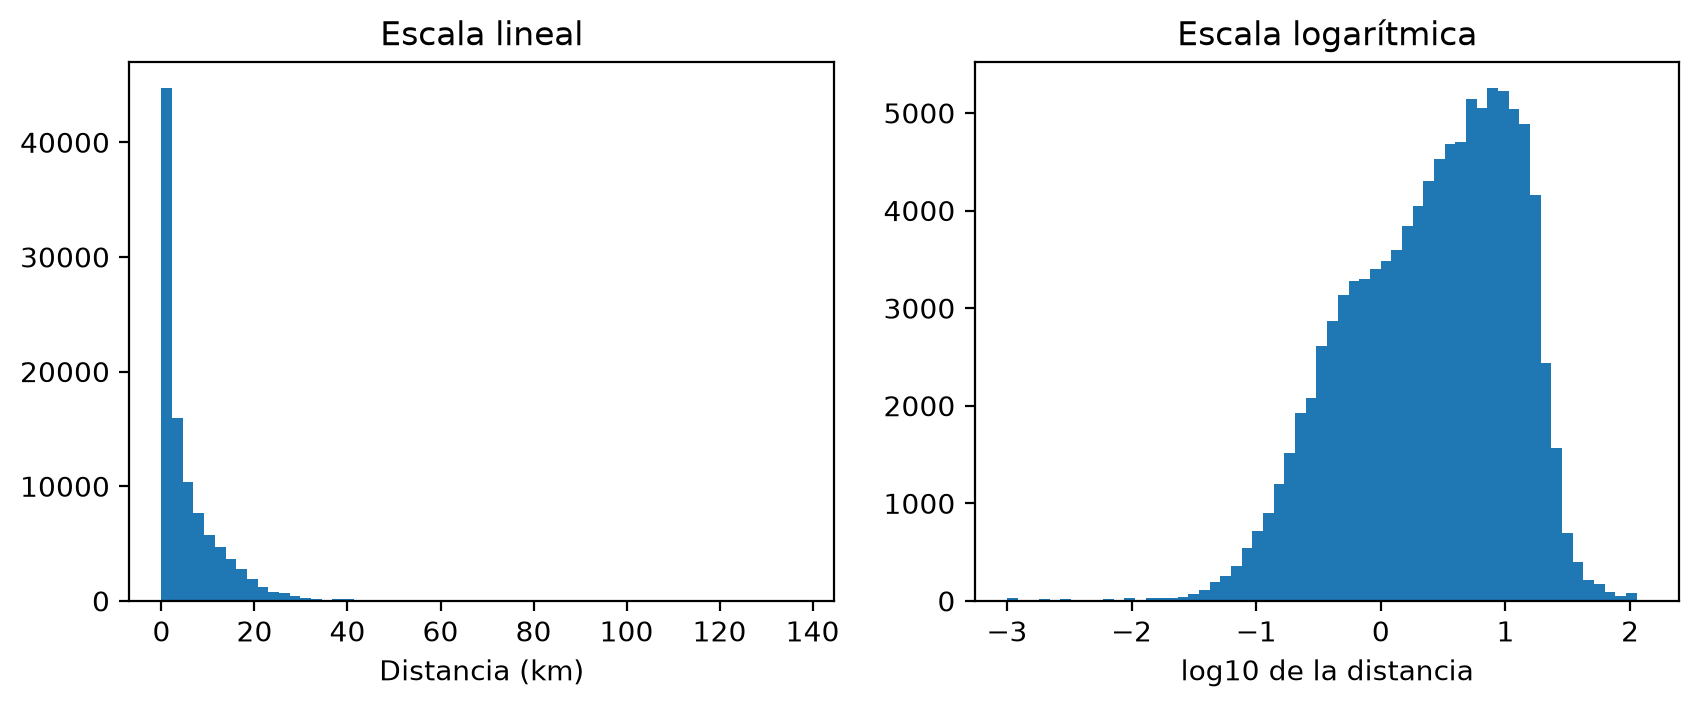

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(dist_pos, bins=60)
axes[0].set_title("Escala lineal")
axes[0].set_xlabel("Distancia (km)")
axes[1].hist(np.log10(dist_pos), bins=60)
axes[1].set_title("Escala logarítmica")
axes[1].set_xlabel("log10 de la distancia")
plt.show()

En log10, un 0 es 1 km y un 1 es 10 km: cada paso del eje multiplica por 10. Y los números negativos son las fracciones de kilómetro: −1 es 0,1 km (100 metros), −2 es 0,01 km (10 metros). El logaritmo baja de cero cuando la distancia baja de 1 km; no hay nada raro en esos valores, son los viajes muy cortos. La forma acampanada de la derecha estaba escondida en la barra pegada al borde de la izquierda.

¿Y para qué sirve? Dos usos concretos:

1. **Para explorar honestamente** cualquier variable con cola larga: ingresos, ventas, poblaciones, tiempos. Si su proyecto tiene una variable de dinero o de conteos, casi seguro la va a necesitar en su primer EDA.
2. **Para modelar**: aplicar el logaritmo a una variable es una transformación clásica de feature engineering. Cuando la relación entre x e y es multiplicativa (porcentual), en escala log se vuelve una recta, y la regresión lineal vuelve a servir. Lo veremos en las clases de regresión.

### La misma regresión, tres veces

**Objetivo:** cerrar usando lo aprendido: ¿qué modelo merecen estos datos? Ajustamos la misma regresión de statsmodels tres veces (sin log, con log en la distancia, con log en ambos lados) y comparamos los ajustes con el R² y con los gráficos:

In [28]:
# Sin logaritmo: duración ~ distancia
# Tiempo de viaje con distancia mayor a 0, para evitar problemas con el logaritmo
y = ok.loc[ok["DistKm"] > 0, "TiempoViaje"]

#Variable a predecir: duración del viaje
#Variable predictora: distancia del viaje
modelo_sin = sm.OLS(y, sm.add_constant(dist_pos)).fit()
modelo_sin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            TiempoViaje   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                 4.888e+04
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:19:00   Log-Likelihood:            -4.9052e+05
No. Observations:              102395   AIC:                         9.810e+05
Df Residuals:                  102393   BIC:                         9.811e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.4601      0.113    207.445      0.000      23.238      23.682
DistKm         2.4608      0.011    221.086      0.000       2.439       2.483
==============================================================================
Omnibus:                   139665.830   Durbin-Watson:                   1.432
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        158944666.873
Skew:                           7.302   Prob(JB):                         0.00
Kurtosis:                     195.461   Cond. No.                         12.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [29]:
print("R² sin log:", round(modelo_sin.rsquared, 2))

R² sin log: 0.32


In [30]:
# Transformación logarítmica: duración ~ log(distancia)
modelo_con = sm.OLS(y, sm.add_constant(np.log10(dist_pos))).fit()
print("R² con log:", round(modelo_con.rsquared, 2))

R² con log: 0.34


De 0,32 a 0,34: la mejora es marginal. Pero sabemos que las dos variables tienen una cola larga. Cuando las dos variables son así, la transformación clásica es aplicar el logaritmo en ambos lados:

In [31]:
# El log tampoco acepta duraciones 0: fuera esos viajes
ll = ok[(ok["DistKm"] > 0) & (ok["TiempoViaje"] > 0)]

modelo_ll = sm.OLS(np.log10(ll["TiempoViaje"]),
                   sm.add_constant(np.log10(ll["DistKm"]))).fit()
print("R² log-log:", round(modelo_ll.rsquared, 2))

R² log-log: 0.53


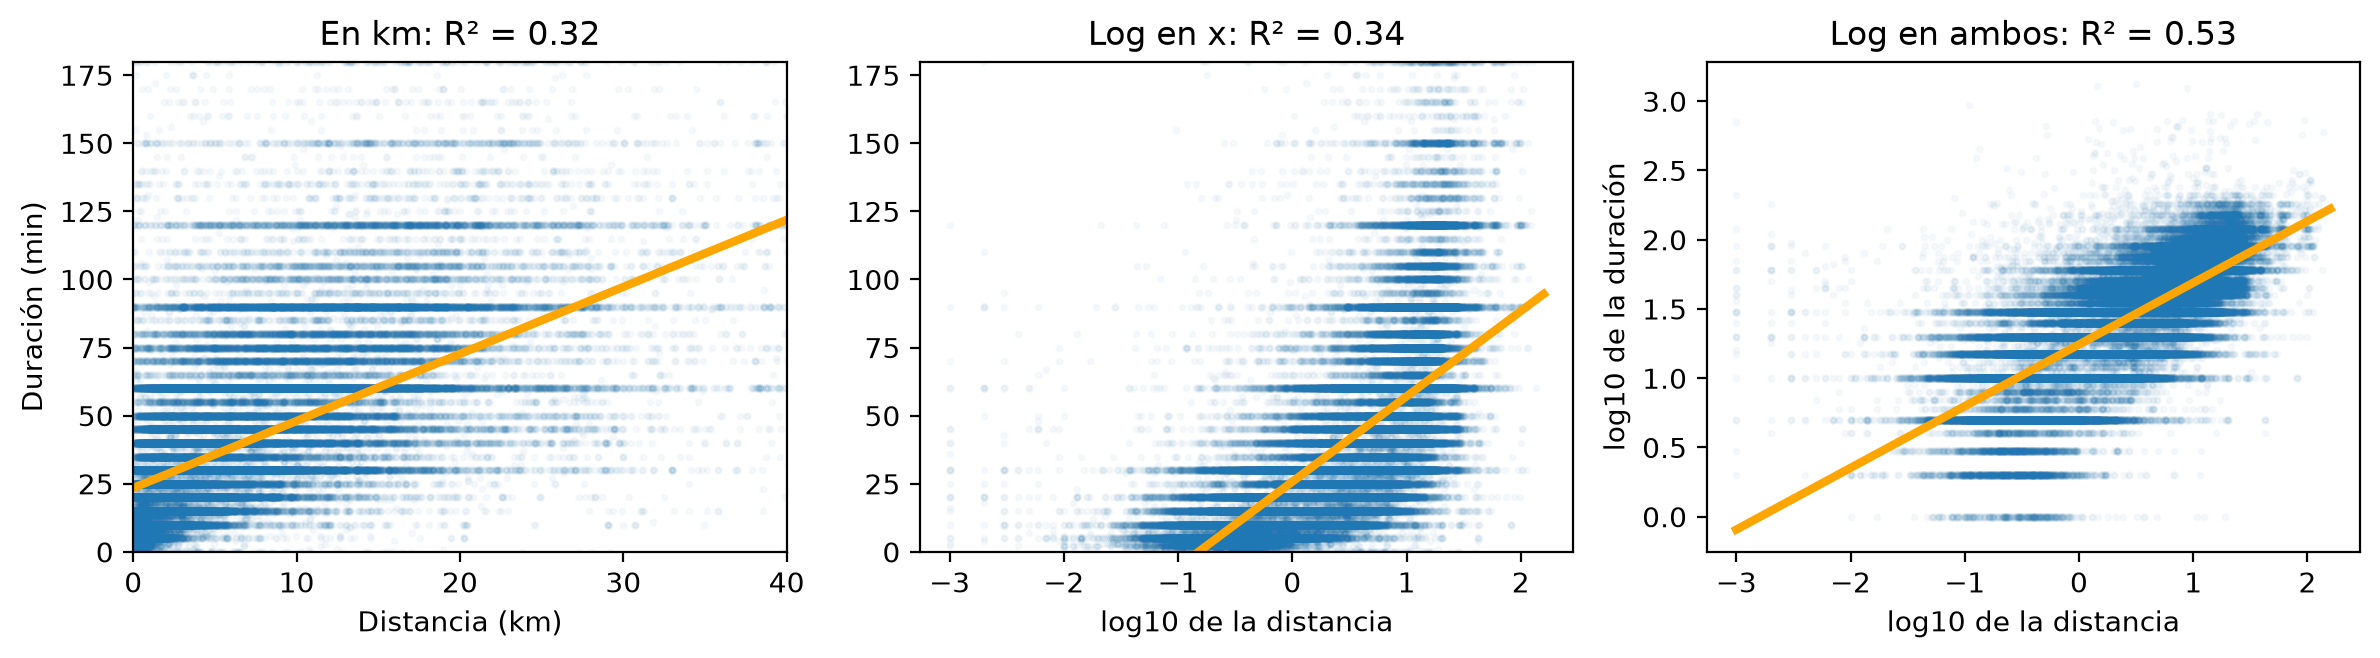

In [32]:
# Los tres modelos, lado a lado; ax.set(...) fija etiquetas,
# límites y título de un panel en una sola llamada
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

# 1. Recta sobre los kilómetros
axes[0].scatter(dist_pos, y, s=4, alpha=0.03)
xs = np.linspace(0.01, 40, 100)
axes[0].plot(xs, modelo_sin.params.iloc[0] + modelo_sin.params.iloc[1] * xs,
             color="orange", lw=3)
axes[0].set(xlim=(0, 40), ylim=(0, 180), xlabel="Distancia (km)",
            ylabel="Duración (min)", title=f"En km: R² = {modelo_sin.rsquared:.2f}")

# 2. Log solo en la distancia
axes[1].scatter(np.log10(dist_pos), y, s=4, alpha=0.03)
xl = np.linspace(-3, 2.2, 100)
axes[1].plot(xl, modelo_con.params.iloc[0] + modelo_con.params.iloc[1] * xl,
             color="orange", lw=3)
axes[1].set(ylim=(0, 180), xlabel="log10 de la distancia",
            title=f"Log en x: R² = {modelo_con.rsquared:.2f}")

# 3. Log en ambos lados
axes[2].scatter(np.log10(ll["DistKm"]), np.log10(ll["TiempoViaje"]), s=4, alpha=0.03)
axes[2].plot(xl, modelo_ll.params.iloc[0] + modelo_ll.params.iloc[1] * xl,
             color="orange", lw=3)
axes[2].set(xlabel="log10 de la distancia", ylabel="log10 de la duración",
            title=f"Log en ambos: R² = {modelo_ll.rsquared:.2f}")

plt.tight_layout()
plt.show()

Los tres paneles, de izquierda a derecha:

1. **En km**, la nube queda comprimida contra el borde y la recta atraviesa zonas casi sin datos (R² 0,32).
2. **Con log solo en la distancia**, los puntos se reparten, pero la recta no calza con la forma de la nube y para los viajes de menos de 150 metros predice duraciones negativas (R² 0,34): una señal clara de que el modelo no es el adecuado.
3. **Con log en ambos lados**, la nube toma una forma aproximadamente lineal y la recta la describe: el R² sube a 0,53. La razón: las dos variables tienen cola larga, no solo una.

El modelo log-log se lee en forma multiplicativa: la pendiente 0,45 indica que cuando la distancia se multiplica por 10, la duración se multiplica por 10^0,45 ≈ 2,8 (unos 18 minutos en 1 km, 49 en 10 km). 

¿Qué modelo se usaría entonces para estos datos? Al menos este último, y todavía le faltan variables: el modo, la hora del día, la zona. Incorporarlas es exactamente lo que hace la regresión múltiple, el paso que damos ahora. Lo que muestra este cierre: transformar variables (feature engineering) puede mejorar un modelo tanto como elegir bien las variables, y el R² permite comparar las alternativas.

Con esto queda cerrado el arco de la clase 3: de la correlación a un modelo que ya se puede transformar, comparar y mejorar. Y quedó pedido el siguiente paso: más variables.

## 4. Regresión múltiple

**Objetivo:** pasar de una variable explicativa a varias: el mismo método de mínimos cuadrados, ahora con más de un predictor.

La regresión múltiple modela

$$\hat{y} = a + b_1\,x_1 + b_2\,x_2 + \dots + b_k\,x_k$$

donde $\hat{y}$ es el valor predicho, cada $x_j$ es una variable explicativa, cada $b_j$ dice cuánto cambia la predicción por una unidad de $x_j$ **manteniendo las demás constantes**, y $a$ es el intercepto. La frase en negrita es la gracia de la múltiple: cada coeficiente aísla el efecto de su variable.

El ejemplo de hoy: la duración del viaje según la distancia y el modo.

### Duración con distancia y modo

**Objetivo:** decidir qué agregar al modelo log-log del cierre anterior, y agregarlo.

**Qué queremos explicar:** la duración del viaje (en log10). **Con qué variables:** la distancia (en log10) y lo que decidamos agregar.

Lo que ya sabemos: la duración correlaciona con la distancia (r = 0,57; Spearman 0,76) y el modelo log-log explica el 53% de su variabilidad. ¿Qué más podría explicarla? Primero, las candidatas numéricas que trae el hogar:

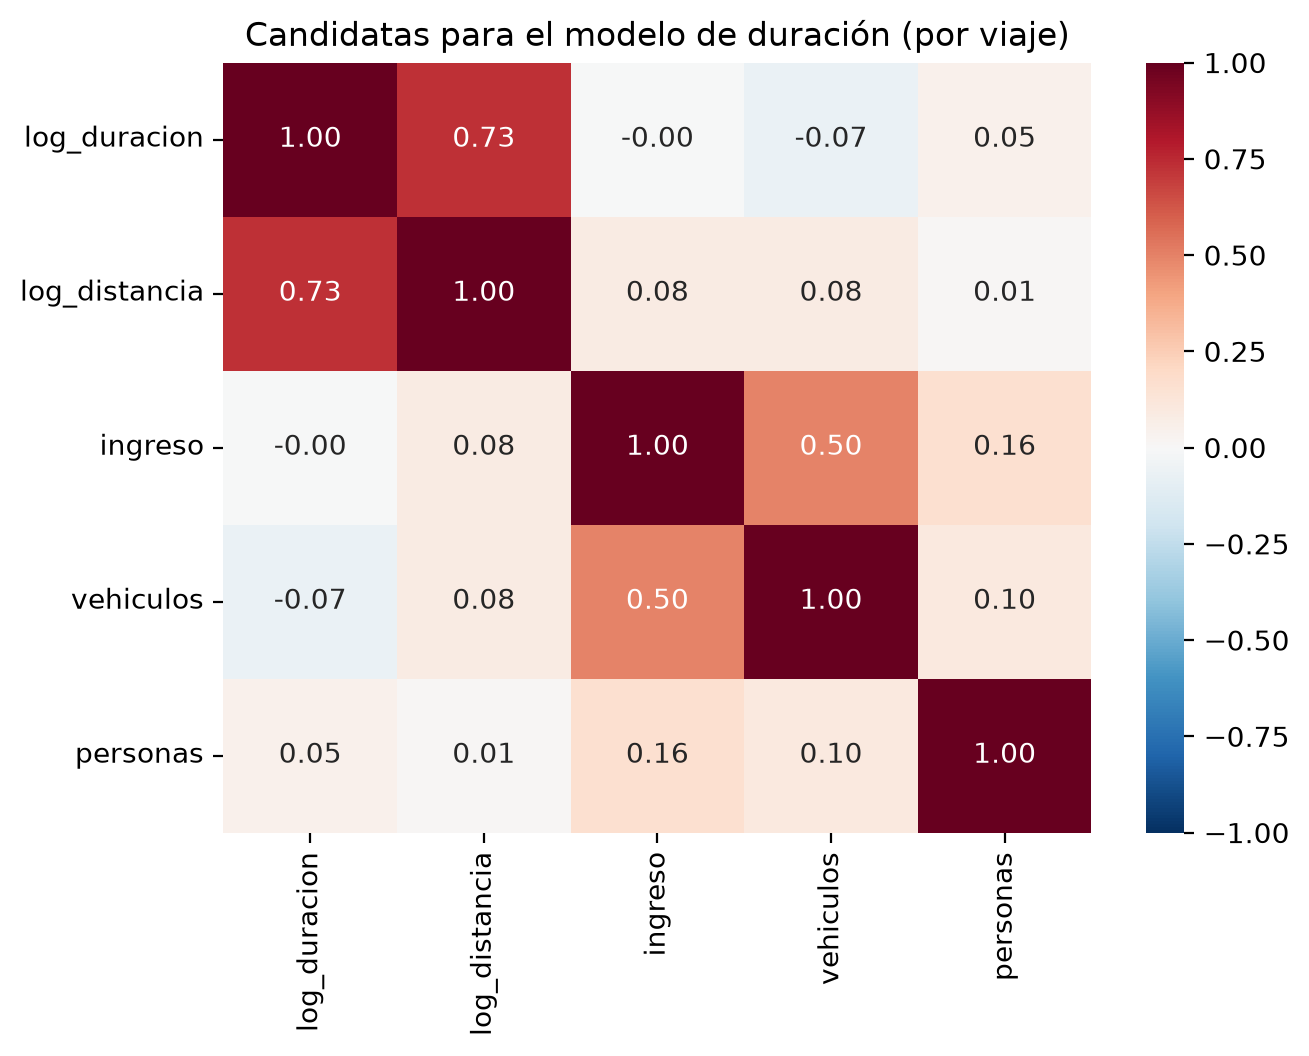

In [33]:
# El mapa de correlaciones, como en vehículos: duración y distancia
# en log (así entran al modelo) más las numéricas del hogar
ll_hogar = ll.merge(hogares[["Hogar", "IngresoHogar", "NumVeh", "NumPer"]], on="Hogar")
mapa = pd.DataFrame({
    "log_duracion": np.log10(ll_hogar["TiempoViaje"]),
    "log_distancia": np.log10(ll_hogar["DistKm"]),
    "ingreso": ll_hogar["IngresoHogar"] / 1e6,
    "vehiculos": ll_hogar["NumVeh"],
    "personas": ll_hogar["NumPer"],
}).corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(mapa, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Candidatas para el modelo de duración (por viaje)")
plt.show()

La fila de la duración: la distancia (0,73 en log) es el motor; el ingreso da **0,00**, los vehículos −0,07 y las personas 0,05. Ojo con el ingreso: en la clase 3 su correlación con la duración era −0,34, pero eso era **entre comunas**. Un promedio por comuna esconde la variabilidad de los viajes individuales, y a nivel de viaje la relación desaparece: la escala del análisis cambia la respuesta.

Las numéricas del hogar no ayudan. Pero el mapa solo ve numéricas: las candidatas **categóricas** (el modo, el período del día, el propósito) hay que mirarlas con groupby. Traemos el modo de cada viaje:

In [34]:
# El modo de cada viaje, con los merges de la clase 3
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

ll_modo = (ll
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID"))
ll_modo["ModoAgrupado"] = ll_modo["NombreModo"].where(
    ~ll_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")
len(ll_modo)

102223

In [35]:
ll_modo.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorFindesemanaEstival,CodigoTiempo,DistEuclidiana,DistManhattan,Imputada,DistKm,ModoDifusion,ID,NombreModo,ModoAgrupado
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,NaN,0.0,5387,7608,0,5.387,2,2,Bip!,Bip! (solo o combinado)
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,NaN,0.0,18841,26100,0,18.841,2,2,Bip!,Bip! (solo o combinado)
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,NaN,0.0,18841,26100,0,18.841,2,2,Bip!,Bip! (solo o combinado)
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,NaN,0.0,13392,17589,0,13.392,2,2,Bip!,Bip! (solo o combinado)
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,NaN,0.0,13392,17589,0,13.392,2,2,Bip!,Bip! (solo o combinado)


In [36]:
# Por modo: duración media y distancia mediana
ll_modo.groupby("ModoAgrupado").agg(
    duracion_media=("TiempoViaje", "mean"),
    distancia_mediana=("DistKm", "median"),
    viajes=("TiempoViaje", "size"),
).round(1).sort_values("duracion_media", ascending=False)

,duracion_media,distancia_mediana,viajes
ModoAgrupado,,,
Bip! (solo o combinado),61.8,7.5,34659
Otros,46.1,4.0,7967
Taxi Colectivo,32.1,2.7,3400
Auto,31.5,4.4,25046
Taxi,25.0,2.2,1595
Bicicleta,24.7,1.6,3425
Caminata,14.9,0.4,26131


Contraste enorme: Bip! 62 minutos, auto 32, caminata 15. Pero la segunda columna avisa: los viajes en Bip! también son más largos en distancia (7,5 km contra 0,4 de caminata). Comparar duraciones a secas mezcla el modo con la distancia; por eso el modelo múltiple: controla la distancia y deja el efecto del modo **a igual distancia**.

**Decisión:** agregamos el modo. Es la candidata de mayor contraste, responde una pregunta de equidad, y como es texto nos obliga a aprender cómo entra una categórica al modelo. El período del día, la otra candidata fuerte (punta mañana 60 minutos, fuera de punta 32), queda para el ejercicio.

Una categórica no entra tal cual a la fórmula: se convierte en **variables indicadoras** (dummies) con `pd.get_dummies`, una columna 0/1 por categoría. Una categoría se deja fuera como **referencia** (aquí, el auto), y cada coeficiente se lee "comparado con un viaje en auto".

In [37]:
# Las dummies: una columna 0/1 por modo; el auto, de referencia
dummies = pd.get_dummies(ll_modo["ModoAgrupado"]).astype(float).drop(columns=["Auto"])
dummies.head()

,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0


In [38]:
# El texto original al lado de sus columnas 0/1: un solo 1 por fila,
# y toda en 0 si el viaje es en auto
pd.concat([ll_modo[["ModoAgrupado"]], dummies], axis=1).head(8)

,ModoAgrupado,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
0,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
1,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
2,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
3,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
4,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
5,Auto,0.0,0.0,0.0,0.0,0.0,0.0
6,Auto,0.0,0.0,0.0,0.0,0.0,0.0
7,Auto,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
X = sm.add_constant(pd.concat(
    [np.log10(ll_modo["DistKm"]).rename("log_dist"), dummies], axis=1))
modelo_modo = sm.OLS(np.log10(ll_modo["TiempoViaje"]), X).fit()

print("R² solo distancia:", round(modelo_ll.rsquared, 2),
      "| con modo:", round(modelo_modo.rsquared, 2))


R² solo distancia: 0.53 | con modo: 0.6


In [40]:
print(modelo_modo.params.round(2))

const                      1.15
log_dist                   0.37
Bicicleta                  0.07
Bip! (solo o combinado)    0.27
Caminata                   0.03
Otros                      0.20
Taxi                       0.01
Taxi Colectivo             0.13
dtype: float64


El modelo ajustado quedó

$$\widehat{\log_{10}(\text{duración})} = 1{,}15 + 0{,}37\,\log_{10}(\text{dist}) + 0{,}27\,\text{Bip!} + \dots$$

donde los puntos suspensivos son las dummies de los demás modos. El R² sube de 0,53 a 0,60, y los coeficientes de las dummies se leen en potencias de 10, igual que en el modelo log-log: $10^{0{,}27} \approx 1{,}87$ para Bip! significa que, **a igual distancia**, un viaje en transporte público tarda casi el doble que uno en auto. El taxi queda prácticamente igual al auto (1,02) y la caminata apenas encima (1,07). Un hallazgo de equidad urbana sacado de un modelo de tres líneas: el tiempo castiga al transporte público.

Dos advertencias para llevarse: los coeficientes describen **asociación**, no causalidad; y elegir variables, revisar diagnósticos y decidir qué es significativo es justamente el contenido de las clases 5, 6 y 7.

**Objetivo:** leer la dummy con números: el mismo viaje de 5 km, en auto y en Bip!.

Como el modelo está en log, la dummy **suma** 0,27 al log de la duración. Y sumar en log es multiplicar en la escala original. Hagamos la cuenta:

In [41]:
# El mismo viaje de 5 km, con la dummy en 0 (auto) y en 1 (Bip!)
b = modelo_modo.params
log_auto = b["const"] + b["log_dist"] * np.log10(5)      # Bip! = 0
log_bip = log_auto + b["Bip! (solo o combinado)"]         # Bip! = 1

print("auto:", round(10**log_auto, 1), "min | Bip!:", round(10**log_bip, 1), "min")
print("razón:", round(10**log_bip / 10**log_auto, 2), "= 10 elevado a", round(b["Bip! (solo o combinado)"], 2))

auto: 25.6 min | Bip!: 47.8 min
razón: 1.87 = 10 elevado a 0.27


Paso a paso, con la ecuación completa (todas las dummies):

$$\log_{10}(\text{dur}) = 1{,}15 + 0{,}37\,\log_{10}(\text{dist}) + 0{,}07\,\text{Bici} + 0{,}27\,\text{Bip!} + 0{,}03\,\text{Cam} + 0{,}20\,\text{Otros} + 0{,}01\,\text{Taxi} + 0{,}13\,\text{Colect}$$

En auto, 5 km (log10 5 = 0,70) y todas las dummies en 0:

$$1{,}15 + 0{,}37 \cdot 0{,}70 + 0{,}07 \cdot 0 + 0{,}27 \cdot 0 + 0{,}03 \cdot 0 + 0{,}20 \cdot 0 + 0{,}01 \cdot 0 + 0{,}13 \cdot 0 = 1{,}41 \Rightarrow \text{dur} = 10^{1{,}41} = 25{,}6 \text{ min}$$

En Bip!, 5 km y solo la dummy de Bip! en 1:

$$1{,}15 + 0{,}37 \cdot 0{,}70 + 0{,}07 \cdot 0 + 0{,}27 \cdot 1 + 0{,}03 \cdot 0 + 0{,}20 \cdot 0 + 0{,}01 \cdot 0 + 0{,}13 \cdot 0 = 1{,}68 \Rightarrow \text{dur} = 10^{1{,}68} = 47{,}8 \text{ min}$$

La razón 47,8 / 25,6 = 1,87 es exactamente 10^0,27. Esa es la lectura de una dummy en un modelo en log: su coeficiente, elevado 10, es **cuántas veces** cambia la variable respecto de la referencia, a igual valor de las demás.

¿Por qué se **dividen** los dos tiempos y no se restan? Porque la dummy actúa en la escala log, y una resta en log es una división en la escala original:

$$\log_{10}(47{,}8) - \log_{10}(25{,}6) = 0{,}27 \quad\Longleftrightarrow\quad \frac{47{,}8}{25{,}6} = 10^{0{,}27} = 1{,}87$$

Si restáramos minutos, el resultado dependería de la distancia: a 5 km la resta es de 22 minutos, a 1 km sería cerca de la mitad y a 20 km casi el doble. La razón, en cambio, es 1,87 a cualquier distancia: por eso es la lectura correcta del coeficiente. Sin log, la lectura sería aditiva: tantos minutos más, a igual distancia.

### Leer el modelo: R² y el valor p

**Objetivo:** entender los dos números que acompañan a toda regresión: cuánto explica el modelo y si cada variable aporta más que el azar.

El **R²** mide la fracción de la variabilidad de $y$ que el modelo explica:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

donde $y_i$ es el valor observado, $\hat{y}_i$ el que predice el modelo e $\bar{y}$ la media de $y$. El numerador suma los errores del modelo al cuadrado; el denominador es la variabilidad total. R² = 0 significa que el modelo no explica nada más que la media; R² = 1, que predice exacto. Nuestro 0,60 se lee: la distancia y el modo explican el 60% de la variabilidad del log de la duración entre viajes; la distancia sola explicaba el 53%.

El **valor p** de un coeficiente responde una sola pregunta sobre esa variable: si en la población (la ciudad) ese modo no tuviera ningún efecto sobre la duración, es decir, si su coeficiente real fuera cero, ¿qué tan raro sería obtener en una muestra como esta un coeficiente como el nuestro, solo por azar del muestreo? Un p muy chico dice "esto no parece azar". En el `summary()` es la columna `P>|t|`; de dónde sale, está en las slides de hoy:

In [42]:
print("R² solo distancia:", round(modelo_ll.rsquared, 3), "| con modo:", round(modelo_modo.rsquared, 3))

# Los valores p de cada coeficiente
modelo_modo.pvalues.round(4)

R² solo distancia: 0.533 | con modo: 0.602


const                      0.0000
log_dist                   0.0000
Bicicleta                  0.0000
Bip! (solo o combinado)    0.0000
Caminata                   0.0000
Otros                      0.0000
Taxi                       0.0761
Taxi Colectivo             0.0000
dtype: float64

### Advertencia: el R² ajustado

El R² **nunca baja** al agregar una variable, aunque sea ruido: mínimos cuadrados siempre puede usar un coeficiente más para acomodar un poco mejor los datos. Por eso, para comparar modelos con distinto número de variables se usa el **R² ajustado**, que descuenta cada variable extra:

$$R^2_{\text{adj}} = 1 - (1 - R^2)\,\frac{n - 1}{n - k - 1}$$

donde $n$ es el número de observaciones y $k$ el de variables explicativas. Si la variable nueva aporta menos de lo que se esperaría por azar, el ajustado baja. En statsmodels es `rsquared_adj` (en el `summary()`, "Adj. R-squared"). Comparemos los dos en los modelos de la duración:

In [43]:
modelos = {
    "log duración ~ log distancia": modelo_ll,
    "log duración ~ log distancia + modo": modelo_modo,
}
for nombre, m in modelos.items():
    print(f"{nombre:40s} n = {int(m.nobs):>6}  k = {int(m.df_model)}  "
          f"R² = {m.rsquared:.4f}  ajustado = {m.rsquared_adj:.4f}")

log duración ~ log distancia             n = 102223  k = 1  R² = 0.5334  ajustado = 0.5334
log duración ~ log distancia + modo      n = 102223  k = 7  R² = 0.6023  ajustado = 0.6023


Con 102 mil viajes el ajustado es idéntico al R² hasta el tercer decimal, así que ninguna conclusión cambia. Pero con pocos datos la diferencia es grande: un R² de 0,266 con n = 30 y k = 3 se convierte en un ajustado de 0,18. En sus proyectos, con cientos de filas y no cien mil, comparen modelos con el R² ajustado.

## 5. La pendiente también se mueve: bootstrap

**Objetivo:** ver cuánto se movería la pendiente de las comunas con otra muestra, y entender el error estándar que statsmodels imprime.

La pregunta pendiente desde la clase 3: la duración media de los viajes baja 4,8 minutos por cada millón de ingreso medio de la comuna, con 45 comunas. Esa pendiente, la $b$ de la recta $\text{duración} = a + b \cdot \text{ingreso}$ (el **coef** del ingreso en el summary), es un número que sale de una muestra: con otras comunas saldría otra. Primero, la recta cuya pendiente vamos a mover, sobre las 45 comunas de la sección 1:

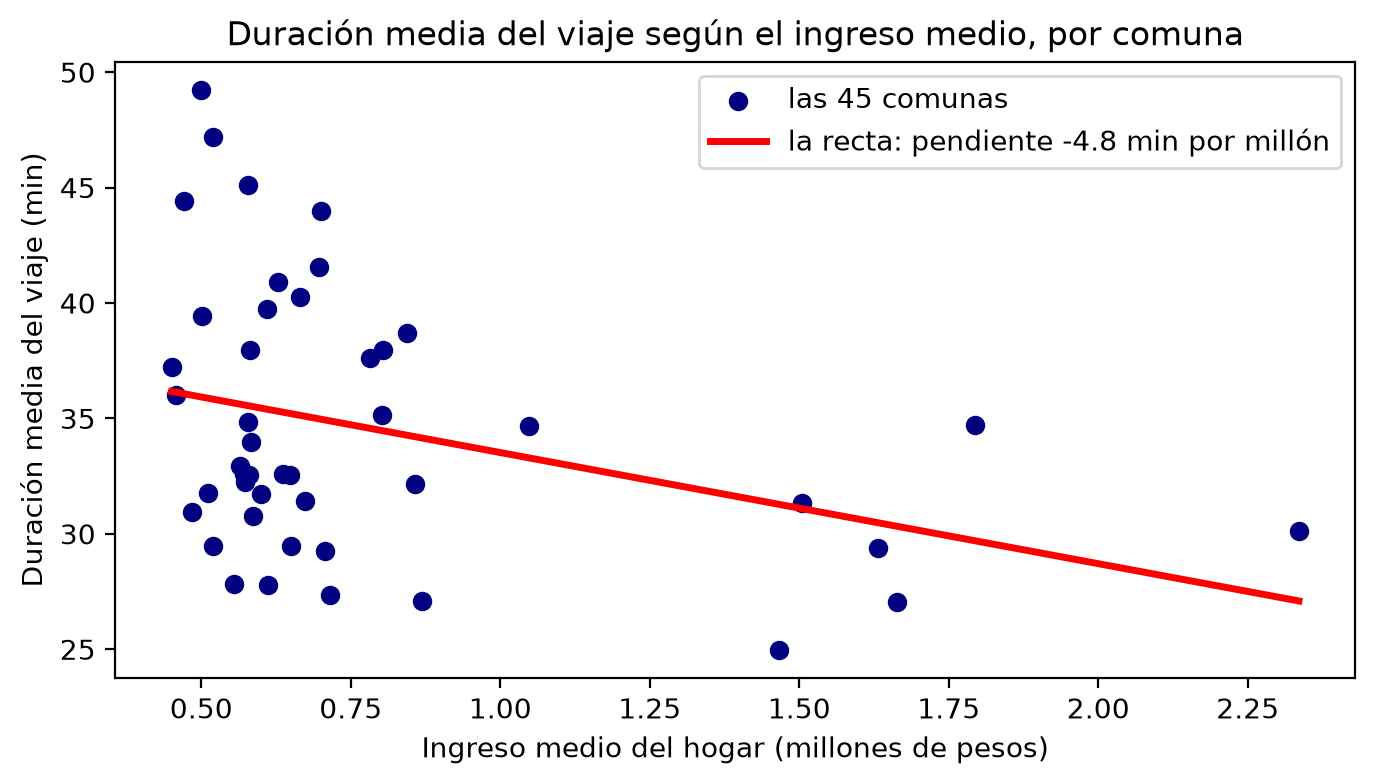

In [44]:
x = por_comuna["ingreso"].values / 1e6   # el ingreso, en millones
y = por_comuna["duracion"].values
b_observada, a_observada = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(x, y, color="navy", label="las 45 comunas")
grilla = np.linspace(x.min(), x.max(), 50)
ax.plot(grilla, a_observada + b_observada * grilla, color="red", lw=2.5,
        label=f"la recta: pendiente {b_observada:.1f} min por millón")
ax.set(xlabel="Ingreso medio del hogar (millones de pesos)", ylabel="Duración media del viaje (min)",
       title="Duración media del viaje según el ingreso medio, por comuna")
ax.legend()
plt.show()

Esa pendiente de −4,8 salió de estas 45 comunas. Con otras 45 comunas, los puntos serían otros y la recta también. Pero no hay una población de comunas de donde sacar otra muestra.

El **bootstrap** (Efron y Tibshirani, 1993) trata la muestra como si fuera la población: toma las 45 comunas, saca 45 **con reemplazo**, ajusta la recta, y lo repite miles de veces. Sacar con reemplazo significa sacar una comuna al azar, anotarla y devolverla a la bolsa antes de sacar la siguiente, de modo que puede volver a salir; no es quitar una comuna y poner otra. Así algunas comunas se repiten y otras quedan fuera. La distribución de las pendientes obtenidas es una estimación de la distribución muestral de la pendiente, sin suponer nada.

¿De dónde salen muestras distintas si solo hay 45 puntos? De sacar **con reemplazo**. Sin reemplazo no serviría: sacar 45 de 45 devuelve siempre las mismas 45 comunas y la misma recta. Con reemplazo cada extracción es independiente, así que una comuna puede salir dos o tres veces mientras otra no sale: es la forma de imitar otra muestra de 45 comunas de la ciudad, usando la muestra como si fuera la población. Veamos una:

In [45]:
rng = np.random.default_rng(42)   # generador con semilla: los resultados se repiten


In [67]:
# rng.integers: 45 índices al azar entre 0 y 44, con repetición
idx = rng.integers(0, len(x), len(x))
idx


array([15, 40,  4,  1, 38, 23,  9,  1, 28, 18, 13, 44, 10, 39, 20,  8, 32,
       37, 10, 25,  4, 29, 21, 37, 24, 11, 29, 17, 20, 27, 17, 10,  6, 43,
       13, 37, 11, 32,  5, 11, 42, 41,  8, 22, 25])

In [68]:
#np.bincount(idx) devuelve un arreglo donde la posición i contiene cuántas veces aparece el número i en idx
veces = np.bincount(idx, minlength=len(x))
veces

array([0, 2, 0, 0, 2, 1, 1, 0, 2, 1, 3, 3, 0, 2, 0, 1, 0, 2, 1, 0, 2, 1,
       1, 1, 1, 2, 0, 1, 1, 2, 0, 0, 2, 0, 0, 0, 0, 3, 1, 1, 1, 1, 1, 1,
       1])

In [70]:
print(pd.DataFrame({"comuna": por_comuna["Comuna"].values, "veces que salió": veces}).head(8))


            comuna  veces que salió
0             BUIN                0
1  CALERA DE TANGO                2
2        CERRILLOS                0
3      CERRO NAVIA                0
4           COLINA                2
5         CONCHALI                1
6        EL BOSQUE                1
7         EL MONTE                0


In [71]:
print(f"no salieron: {(veces == 0).sum()} comunas | una vez: {(veces == 1).sum()} | dos o más: {(veces >= 2).sum()}")
print(f"pendiente observada: {b_observada:.2f} | pendiente de esta remuestra: {np.polyfit(x[idx], y[idx], 1)[0]:.2f}")

no salieron: 15 comunas | una vez: 18 | dos o más: 12
pendiente observada: -4.81 | pendiente de esta remuestra: -7.14


Otros puntos, otra recta. Cinco remuestras más, para ver que cada una da una pendiente distinta:

In [74]:
x #el ingreso, en millones

array([0.61158478, 0.60931181, 0.57868273, 0.45775856, 0.63652456,
       0.64983186, 0.56483936, 0.50180934, 0.5112643 , 1.0487363 ,
       0.64898454, 0.47066644, 0.70705527, 0.78236432, 0.60011534,
       0.49927929, 1.79426838, 0.80292872, 1.63180488, 2.33546874,
       0.57288521, 0.48465759, 0.85671199, 0.69683915, 0.45033038,
       0.57802717, 0.5792096 , 0.51980665, 0.84348239, 0.80325354,
       1.46540973, 0.57173597, 0.66461292, 0.70070231, 0.58323385,
       0.67280746, 0.58225916, 0.51992397, 0.55475143, 0.86897562,
       0.58615712, 0.7149814 , 0.62746881, 1.66344926, 1.50428686])

In [76]:
x[idx]

array([0.57802717, 1.79426838, 1.46540973, 0.60011534, 0.57802717,
       0.57288521, 0.45033038, 1.50428686, 0.51980665, 0.57173597,
       1.79426838, 0.64983186, 1.66344926, 0.64983186, 0.84348239,
       0.56483936, 0.66461292, 0.86897562, 0.60931181, 0.56483936,
       0.48465759, 0.57288521, 0.64983186, 0.84348239, 0.47066644,
       0.58225916, 0.78236432, 0.60011534, 1.46540973, 0.64898454,
       0.70705527, 0.63652456, 1.0487363 , 0.45775856, 0.64983186,
       0.56483936, 0.5792096 , 1.46540973, 0.69683915, 0.45775856,
       1.50428686, 0.80325354, 0.55475143, 0.55475143, 1.79426838])

In [72]:
for i in range(5):
    idx = rng.integers(0, len(x), len(x))
    print(f"remuestra {i + 1}: pendiente = {np.polyfit(x[idx], y[idx], 1)[0]:.2f}")

remuestra 1: pendiente = -4.76
remuestra 2: pendiente = -4.50
remuestra 3: pendiente = -6.46
remuestra 4: pendiente = -5.63
remuestra 5: pendiente = -4.31


Cinco pendientes distintas. ¿Y por qué 2.000 y no 30? Con 3 comunas A, B y C, sacar 3 con reemplazo da 10 remuestras distintas (AAA, AAB, AAC, ABB, ABC, ACC, BBB, BBC, BCC, CCC), cada una un conjunto de puntos distinto con su propia recta. Con 45 comunas hay más de $10^{25}$ remuestras posibles, así que 2.000 son todas distintas, y con unas 2.000 el error estándar deja de cambiar: es lo que hace falta para ver la forma completa de la distribución. Ahora sí, 2.000 veces:

In [93]:
pendientes = []
for _ in range(2000):
    idx = rng.integers(0, len(x), len(x))
    pendientes.append(np.polyfit(x[idx], y[idx], 1)[0])
pendientes = np.array(pendientes)



In [86]:
#Desviacion de las 2000 pendientes (error estándar bootstrap)
print(f"Desviación de las 2000 pendientes (error estándar bootstrap): {pendientes.std():.2f}")


Desviación de las 2000 pendientes (error estándar bootstrap): 1.75


In [94]:
np.percentile(pendientes, [2.5, 97.5])

array([-8.97186774, -2.20080661])

**Los percentiles.** `np.percentile(pendientes, [2.5, 97.5])` ordena las 2.000 pendientes y devuelve la que deja el 2,5% por debajo (la número 50 desde abajo) y la que deja el 2,5% por encima (la número 50 desde arriba). Entre ambas queda el 95% central de las remuestras: ese es el **intervalo bootstrap** del 95%, leído directo del histograma, sin suponer forma de campana.

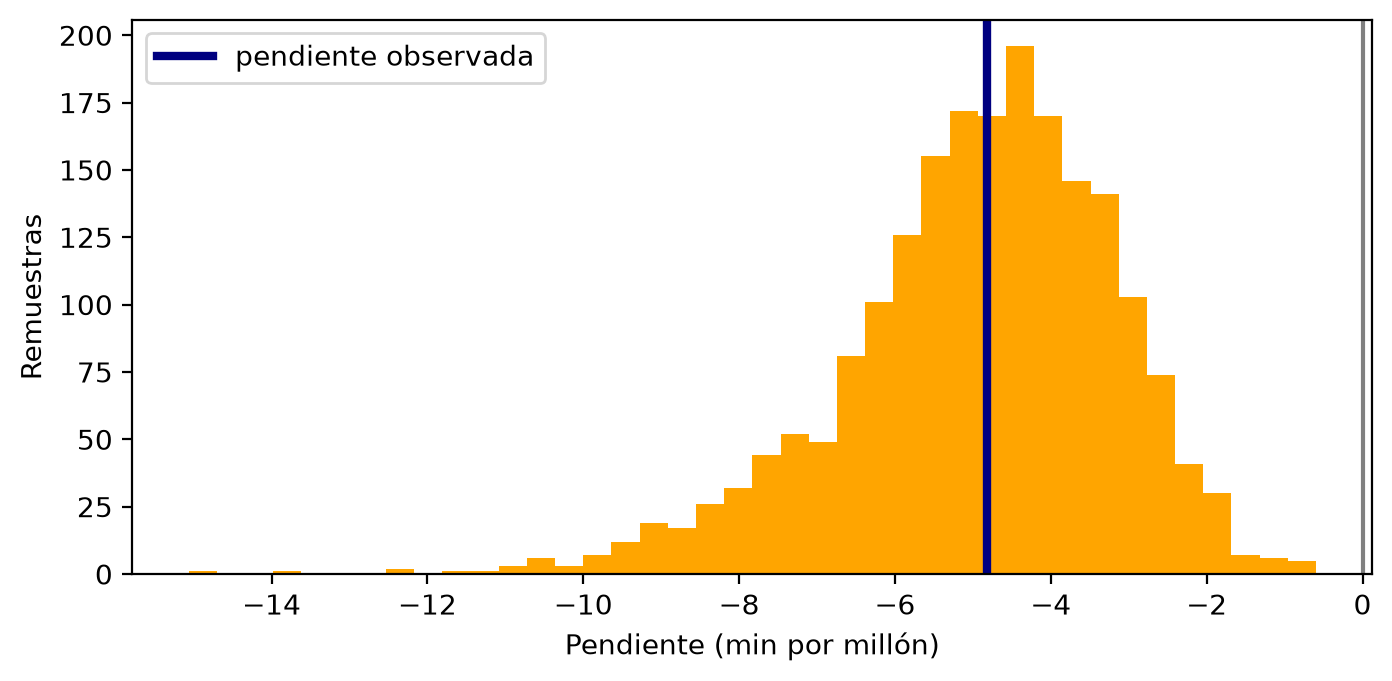

In [87]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(pendientes, bins=40, color="orange")
ax.axvline(b_observada, color="navy", lw=3, label="pendiente observada")
ax.axvline(0, color="gray", lw=1.5)
ax.set(xlabel="Pendiente (min por millón)", ylabel="Remuestras")
ax.legend()
plt.show()

Las 2.000 pendientes forman una campana alrededor de la observada (el teorema central del límite otra vez: un coeficiente es un promedio ponderado de los $y$). Su desviación es el **error estándar de la pendiente**, el mismo concepto que el de la media. Y casi ninguna remuestra llega al 0.

statsmodels calcula ese error estándar con una fórmula, a partir de los residuos y sin remuestrear: es la columna **std err** del summary que hasta ahora no leíamos:

In [79]:
modelo = sm.OLS(por_comuna["duracion"], sm.add_constant(por_comuna["ingreso"] / 1e6)).fit()
modelo.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,38.3352,1.773,21.622,0.000,34.760,41.911
ingreso,-4.8146,2.015,-2.389,0.021,-8.879,-0.750


Por ahora, tres columnas de la fila del ingreso:

- **coef** = −4,81: la pendiente.
- **std err** = 2,02: el error estándar de la pendiente, cerca del que dio el bootstrap.
- **[0.025, 0.975]** = [−8,9; −0,75]: el intervalo de confianza del 95% de la pendiente, coeficiente ± 2,02 · EE (2,02 en lugar de 1,96 por la t de Student, que está en las slides). Es el primer uso del error estándar, ahora para la pendiente.

¿De dónde sale ese 2,02? De los residuos, con una fórmula:

$$EE(b) = \frac{s}{\sqrt{\sum_i (x_i - \bar{x})^2}}, \qquad s = \sqrt{\frac{\sum_i e_i^2}{n - 2}}$$

donde $e_i$ es el residuo de la comuna $i$ (su distancia vertical a la recta); $s$ es la desviación de esos residuos, que reemplaza a $\sigma$, la desviación de los errores alrededor de la recta verdadera, que no se conoce; $x_i - \bar{x}$ es cuánto se aleja el ingreso medio de cada comuna del ingreso medio de todas, y $n - 2$ son las 45 comunas menos los dos parámetros de la recta. La pendiente se mueve menos cuando las comunas están cerca de la recta ($s$ chico) y cuando los ingresos están bien desplegados (la suma grande). A mano:

In [80]:
residuos = modelo.resid
s_res = np.sqrt((residuos ** 2).sum() / (len(por_comuna) - 2))
ingreso_m = por_comuna["ingreso"] / 1e6
sx = np.sqrt(((ingreso_m - ingreso_m.mean()) ** 2).sum())

print(f"s, la desviación de los residuos: {s_res:.2f} min")
print(f"EE(b) = s / raíz(suma (x - x̄)²) = {s_res:.2f} / {sx:.2f} = {s_res / sx:.2f}")
print(f"std err de statsmodels: {modelo.bse['ingreso']:.2f}")

s, la desviación de los residuos: 5.50 min
EE(b) = s / raíz(suma (x - x̄)²) = 5.50 / 2.73 = 2.02
std err de statsmodels: 2.02


Los dos caminos al intervalo, comparados:

In [88]:
intervalo_formula = modelo.conf_int().loc["ingreso"]
print(f"Intervalo de confianza 95% (fórmula): [{intervalo_formula.iloc[0]:.2f}, {intervalo_formula.iloc[1]:.2f}]")

Intervalo de confianza 95% (fórmula): [-8.88, -0.75]


In [89]:

print(f"bootstrap: [{inferior:.2f}, {superior:.2f}]")

bootstrap: [-9.00, -2.08]


In [92]:
print(f"fórmula:   [{intervalo_formula.iloc[0]:.2f}, {intervalo_formula.iloc[1]:.2f}]")

fórmula:   [-8.88, -0.75]


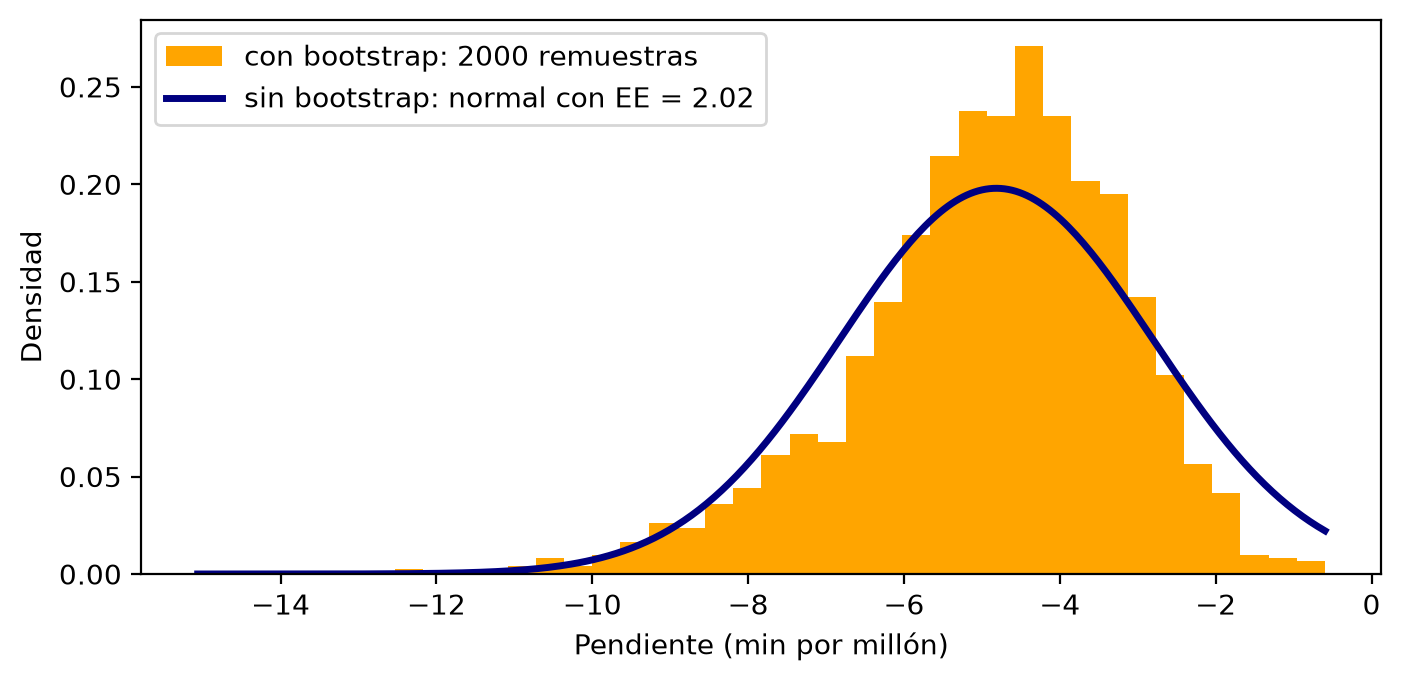

In [91]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(pendientes, bins=40, density=True, color="orange", label="con bootstrap: 2000 remuestras")
grilla = np.linspace(pendientes.min(), pendientes.max(), 300)
ee_formula = modelo.bse["ingreso"]
# stats.norm.pdf: la campana con la pendiente observada y el EE de la fórmula
ax.plot(grilla, stats.norm.pdf(grilla, b_observada, ee_formula), color="navy", lw=2.5,
        label=f"sin bootstrap: normal con EE = {ee_formula:.2f}")
ax.set(xlabel="Pendiente (min por millón)", ylabel="Densidad")
ax.legend()
plt.show()

Y en una tabla, para comparar de un vistazo:

In [83]:
pd.DataFrame({
    "sin bootstrap (fórmula)": [round(b_observada, 2), round(ee_formula, 2),
                               f"[{intervalo_formula.iloc[0]:.2f}, {intervalo_formula.iloc[1]:.2f}]"],
    "con bootstrap": [round(b_observada, 2), round(pendientes.std(), 2),
                      f"[{inferior:.2f}, {superior:.2f}]"],
}, index=["pendiente", "error estándar", "intervalo 95%"])

,sin bootstrap (fórmula),con bootstrap
pendiente,-4.81,-4.81
error estándar,2.02,1.75
intervalo 95%,"[-8.88, -0.75]","[-9.00, -2.08]"


Se parecen, y ninguno incluye el 0. El bootstrap sirve para cualquier estadístico (una mediana, una razón, un coeficiente de un modelo complicado) y no necesita fórmula ni supuestos; la fórmula es instantánea, pero supone cosas sobre los residuos (los supuestos de OLS, en las slides).

---

**Próxima clase (jueves 10-sep):** regresión logística, para una respuesta que es sí o no, y cómo clasificar con ella. Recuerde: el primer análisis exploratorio se entrega el lunes 15 de septiembre.